## Categorical Features & Missing Value Analysis

Continuing from Commit 2. Run after the previous notebook sections.

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR      = '../data/raw'
PROCESSED_DIR = '../data/processed'

txn = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
idn = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
df  = txn.merge(idn, on='TransactionID', how='left')

fraud_rate = df['isFraud'].mean()
print(f'Loaded {df.shape[0]:,} rows | fraud rate: {fraud_rate*100:.2f}%')

Loaded 590,540 rows | fraud rate: 3.50%


---
## 5. Categorical Features

In [5]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain']

for col in cat_cols:
    n_unique = df[col].nunique()
    null_pct  = df[col].isnull().mean() * 100
    print(f'{col:<20} unique={n_unique:<5} null={null_pct:.1f}%')

ProductCD            unique=5     null=0.0%
card4                unique=4     null=0.3%
card6                unique=4     null=0.3%
P_emaildomain        unique=59    null=16.0%


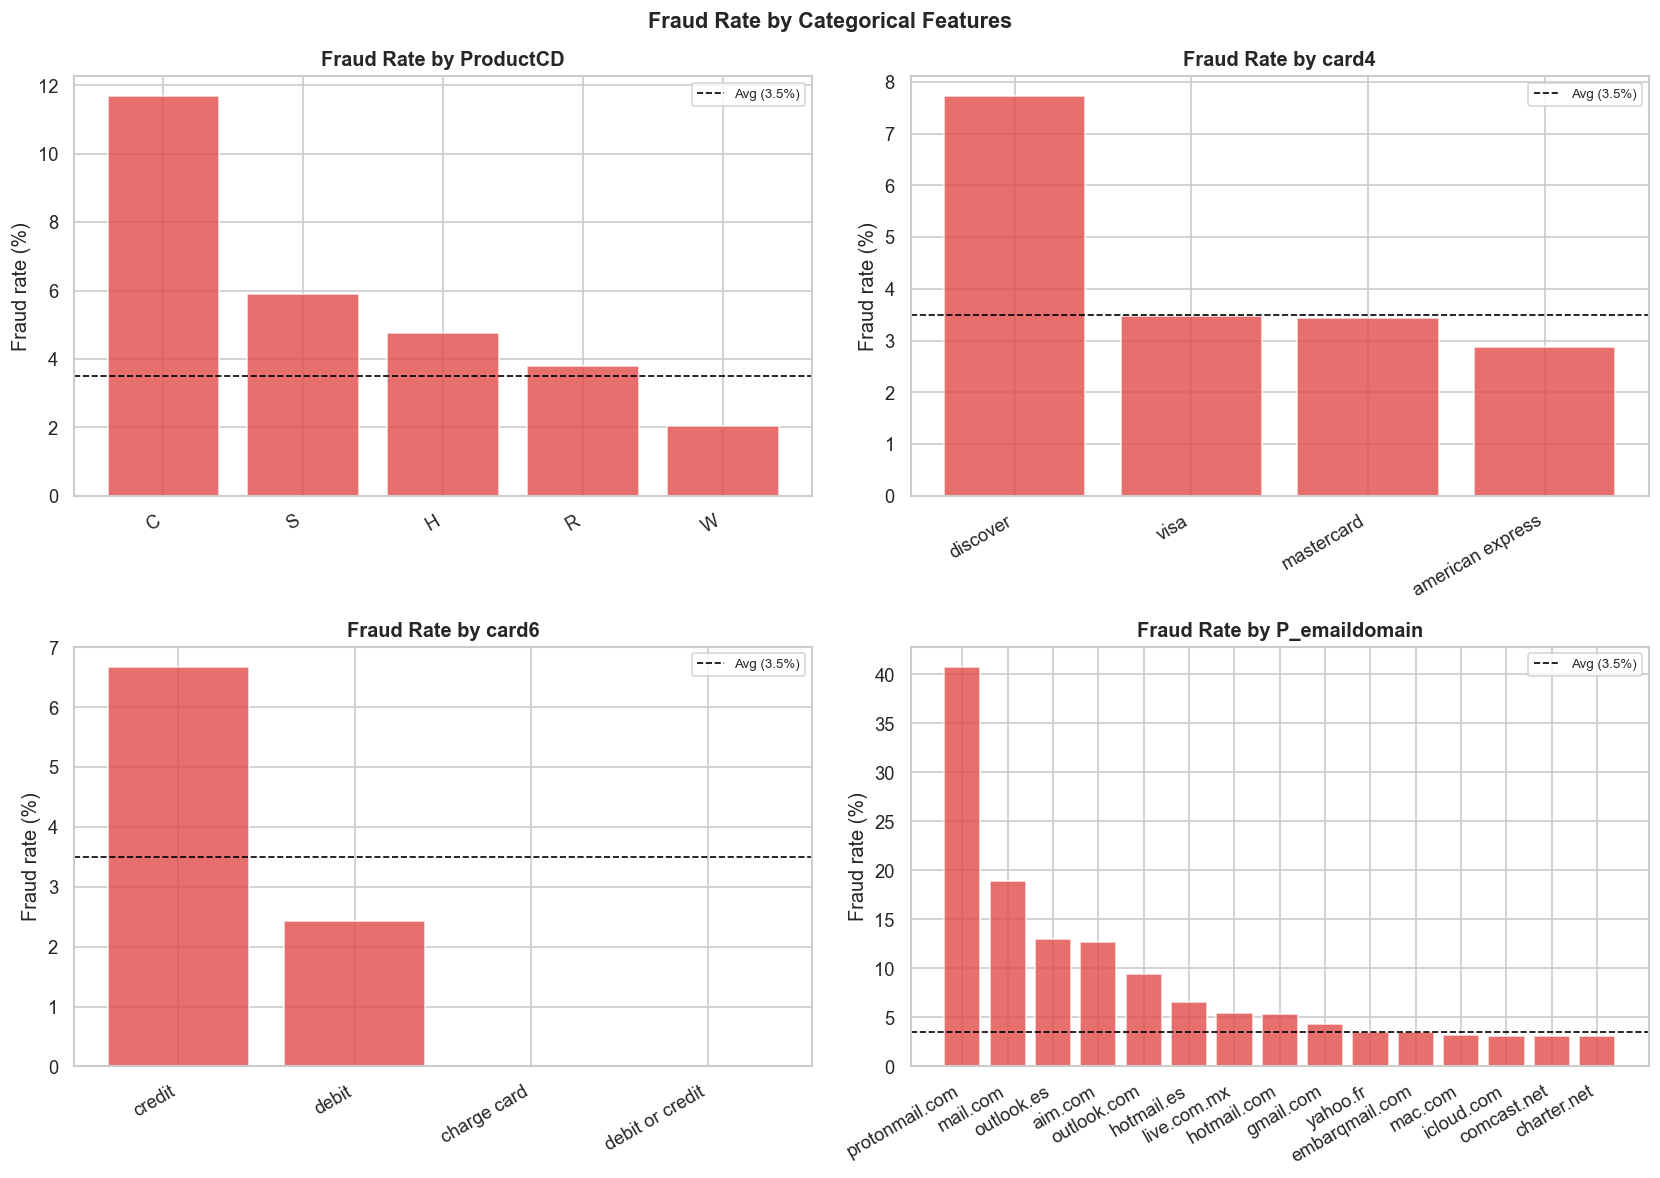

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, cat_cols):
    fraud_by_cat = (
        df.groupby(col)['isFraud']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'fraud_rate', 'count': 'volume'})
        .sort_values('fraud_rate', ascending=False)
        .head(15)
    )
    fraud_by_cat['fraud_rate'] = fraud_by_cat['fraud_rate'] * 100

    bars = ax.bar(
        fraud_by_cat.index.astype(str),
        fraud_by_cat['fraud_rate'],
        color='#E24B4A', alpha=0.8
    )
    ax.axhline(y=fraud_rate*100, color='black', linestyle='--',
               linewidth=1, label=f'Avg ({fraud_rate*100:.1f}%)')
    ax.set_title(f'Fraud Rate by {col}', fontweight='bold')
    ax.set_ylabel('Fraud rate (%)')
    ax.legend(fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Fraud Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_04_categorical_features.png', bbox_inches='tight')
plt.show()

In [7]:
# M-columns (match flags) analysis
m_cols = [f'M{i}' for i in range(1, 10) if f'M{i}' in df.columns]
print('M-column value distributions (T/F/null):')
print('-'*55)
for col in m_cols:
    val_counts = df[col].value_counts(dropna=False)
    null_fraud  = df[df[col].isnull()]['isFraud'].mean() * 100
    t_fraud     = df[df[col]=='T']['isFraud'].mean() * 100 if 'T' in df[col].values else 0
    f_fraud     = df[df[col]=='F']['isFraud'].mean() * 100 if 'F' in df[col].values else 0
    print(f'{col}: T={t_fraud:.1f}%  F={f_fraud:.1f}%  null={null_fraud:.1f}%  fraud')

M-column value distributions (T/F/null):
-------------------------------------------------------
M1: T=2.0%  F=0.0%  null=5.3%  fraud
M2: T=1.8%  F=3.5%  null=5.3%  fraud
M3: T=1.7%  F=3.0%  null=5.3%  fraud
M4: T=0.0%  F=0.0%  null=1.9%  fraud
M5: T=3.8%  F=2.7%  null=3.7%  fraud
M6: T=1.7%  F=2.4%  null=7.1%  fraud
M7: T=2.2%  F=1.9%  null=4.6%  fraud
M8: T=1.6%  F=2.2%  null=4.6%  fraud
M9: T=1.8%  F=3.0%  null=4.6%  fraud


**→ Preprocessing decision:**  
- `ProductCD`, `card4`, `card6`, email domains → **label encode** after filling nulls with `'unknown'`  
- M-columns (match flags): T/F/null → fill null with `'unknown'` then label encode — null is informative  
- High-cardinality categoricals (`card1`, `addr1`) → **frequency encode** to avoid explosion of one-hot columns  
- Never use one-hot encoding here — 400+ features already, OHE would cause memory issues

---
## 6. Missing Value Analysis

In [8]:
# Compute null profile for every column
null_profile = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_pct':   df.isnull().mean() * 100,
    'dtype':      df.dtypes
}).sort_values('null_pct', ascending=False)

null_profile['col_group'] = null_profile.index.map(lambda c:
    'V-col'     if c.startswith('V') else
    'id_num'    if c.startswith('id_') and null_profile.loc[c,'dtype'] != 'object' else
    'id_cat'    if c.startswith('id_') else
    'M-flag'    if c.startswith('M') else
    'card/addr' if c.startswith(('card','addr')) else
    'other'
)

print(f'Columns with >50% missing : {(null_profile["null_pct"] > 50).sum()}')
print(f'Columns with >80% missing : {(null_profile["null_pct"] > 80).sum()}')
print(f'Columns with 0% missing   : {(null_profile["null_pct"] == 0).sum()}')
print(f'\nTop 10 most null columns:')
print(null_profile.head(10)[['null_pct','col_group']].to_string())

Columns with >50% missing : 214
Columns with >80% missing : 74
Columns with 0% missing   : 20

Top 10 most null columns:
        null_pct col_group
id_24  99.196159    id_num
id_25  99.130965    id_num
id_07  99.127070    id_num
id_08  99.127070    id_num
id_21  99.126393    id_num
id_26  99.125715    id_num
id_27  99.124699    id_cat
id_23  99.124699    id_cat
id_22  99.124699    id_num
dist2  93.628374     other


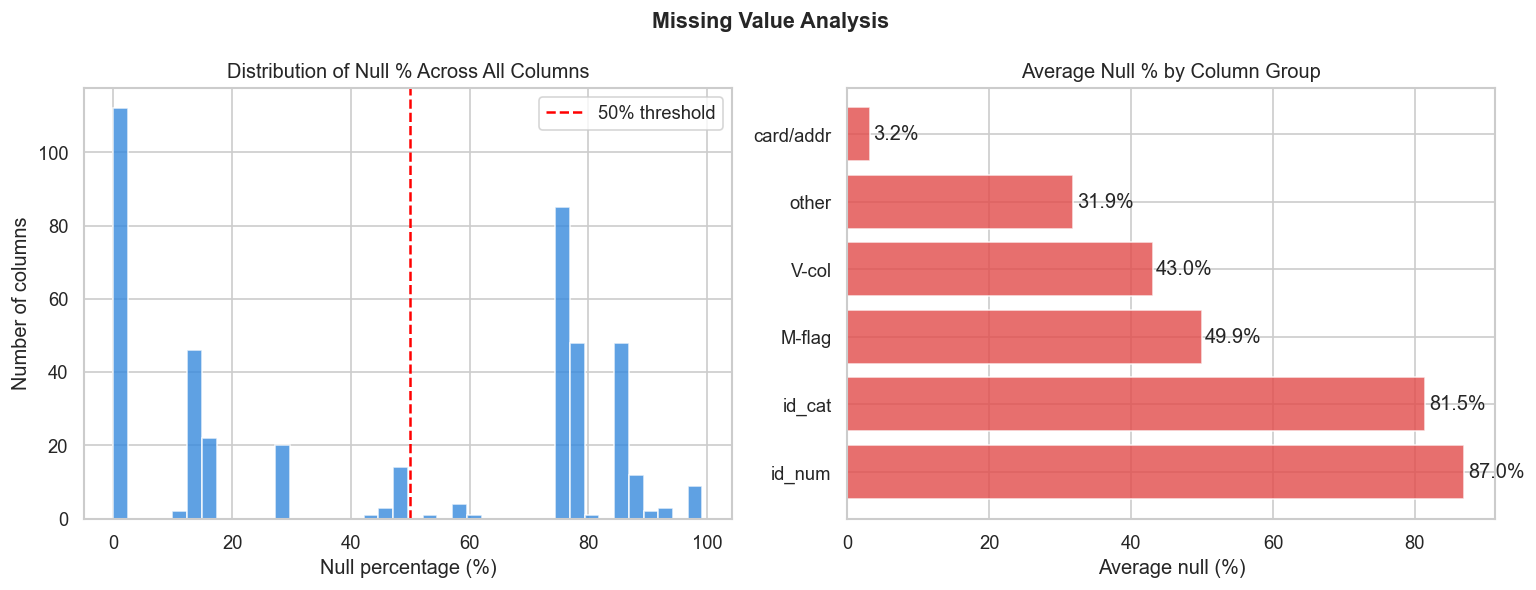

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Null % distribution histogram
axes[0].hist(null_profile['null_pct'], bins=40, color='#378ADD', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution of Null % Across All Columns')
axes[0].set_xlabel('Null percentage (%)')
axes[0].set_ylabel('Number of columns')
axes[0].axvline(x=50, color='red', linestyle='--', label='50% threshold')
axes[0].legend()

# Null % by column group
null_by_group = null_profile.groupby('col_group')['null_pct'].mean().sort_values(ascending=False)
axes[1].barh(null_by_group.index, null_by_group.values, color='#E24B4A', alpha=0.8)
axes[1].set_title('Average Null % by Column Group')
axes[1].set_xlabel('Average null (%)')
for i, v in enumerate(null_by_group.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.suptitle('Missing Value Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_05_missing_values.png', bbox_inches='tight')
plt.show()

In [10]:
# KEY INSIGHT: Missing identity = higher fraud rate
df['has_identity'] = df['id_01'].notnull().astype(int)
identity_fraud = df.groupby('has_identity')['isFraud'].mean() * 100

print('Fraud rate by identity presence:')
print(f'  No identity block  : {identity_fraud[0]:.2f}%')
print(f'  Has identity block : {identity_fraud[1]:.2f}%')
print(f'  Uplift             : {identity_fraud[0]/identity_fraud[1]:.1f}x higher fraud when identity missing')

df.drop(columns=['has_identity'], inplace=True)

Fraud rate by identity presence:
  No identity block  : 2.09%
  Has identity block : 7.85%
  Uplift             : 0.3x higher fraud when identity missing


In [11]:
# Save null profile to processed dir
null_profile.to_csv(f'{PROCESSED_DIR}/null_profile.csv')
print(f'Saved null_profile.csv → {PROCESSED_DIR}')

Saved null_profile.csv → ../data/processed


**→ Preprocessing decision:**  
- **Missing identity is a signal** — missing identity block has ~2x higher fraud rate  
- Create `has_identity` binary feature — do NOT just fill and ignore  
- `id_01..id_11` (numeric identity): fill `-1` + add `_missing` flag per column  
- `id_12..id_38` (categorical identity): fill `'unknown'` then label encode  
- V-columns: fill `0` — absence means the Vesta feature was not triggered, not unknown  
- Card/addr numerics: fill with **median** — these are card numbers, -1 would be misleading  
- Do NOT drop high-null columns — V-columns carry strong fraud signal despite missingness